# **🛠️ Preparación de los Datos**

En esta etapa, prepararemos nuestro conjunto de datos para que los algoritmos de Machine Learning puedan interpretarlos correctamente. Esto incluye:
1. **Extracción y limpieza inicial**: Cargar los datos y eliminar identificadores que no aportan valor predictivo (como el ID del cliente).
2. **Encoding**: Transformar las variables de texto (categóricas) a números.
3. **Verificación de la proporción de Churn**: Analizar si nuestras clases están desbalanceadas.
4. **Balanceo de clases**: Utilizar técnicas como SMOTE para equilibrar los datos si es necesario.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Cargar los datos
df_ml = pd.read_csv("datos_tratados.csv")

# Eliminar la columna customerID (No aporta valor predictivo)
if 'customerID' in df_ml.columns:
    df_ml = df_ml.drop(columns=['customerID'])

# Mostramos las dimensiones y las primeras filas
print("Datos cargados exitosamente. Dimensiones:", df_ml.shape)
display(df_ml.head())

Datos cargados exitosamente. Dimensiones: (7043, 21)


,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Charges.Daily
0,False,Female,False,True,True,9,True,False,DSL,False,...,False,True,True,False,One year,True,Mailed check,65.6,593.30,2.16
1,False,Male,False,False,False,9,True,True,DSL,False,...,False,False,False,True,Month-to-month,False,Mailed check,59.9,542.40,1.97
2,True,Male,False,False,False,4,True,False,Fiber optic,False,...,True,False,False,False,Month-to-month,True,Electronic check,73.9,280.85,2.43
3,True,Male,True,True,False,13,True,False,Fiber optic,False,...,True,False,True,True,Month-to-month,True,Electronic check,98.0,1237.85,3.22
4,True,Female,True,True,False,3,True,False,Fiber optic,False,...,False,True,True,False,Month-to-month,True,Mailed check,83.9,267.40,2.76


### Encoding: Transformación de variables categóricas
Los modelos matemáticos no entienden palabras como "Yes" o "No", solo números. Por lo tanto, convertiremos:
* Las variables binarias (ej. Yes/No, Male/Female) a `1` y `0`.
* Las variables con más de dos categorías (ej. Tipo de contrato, Método de pago) usando **One-Hot Encoding** (creando columnas dummy).

In [12]:
# Estandarizamos valores redundantes
reemplazos = {
    'No internet service': 'No',
    'No phone service': 'No'
}
df_ml.replace(reemplazos, inplace=True)

# Convertimos variables binarias a 0 y 1 manualmente
diccionario_binario = {
    'No': 0,
    'Yes': 1,
    'Male': 0,
    'Female': 1
}

# Aplicamos el diccionario a todo el dataframe
df_ml = df_ml.replace(diccionario_binario)

# Aplicamos One-Hot Encoding a las columnas categóricas restantes
columnas_categoricas = df_ml.select_dtypes(include=['object']).columns.tolist()

if len(columnas_categoricas) > 0:
    df_ml = pd.get_dummies(df_ml, columns=columnas_categoricas, drop_first=True).astype(int)

print("¡Encoding completado! Así lucen nuestros datos ahora (todo numérico):")
display(df_ml.head())

¡Encoding completado! Así lucen nuestros datos ahora (todo numérico):


,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,Charges.Monthly,Charges.Total,Charges.Daily,InternetService_DSL,InternetService_Fiber optic,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,1,9,1,0,0,1,...,65,593,2,1,0,1,0,0,0,1
1,0,0,0,0,0,9,1,1,0,0,...,59,542,1,1,0,0,0,0,0,1
2,1,0,0,0,0,4,1,0,0,0,...,73,280,2,0,1,0,0,0,1,0
3,1,0,1,1,0,13,1,0,0,1,...,98,1237,3,0,1,0,0,0,1,0
4,1,1,1,1,0,3,1,0,0,0,...,83,267,2,0,1,0,0,0,0,1


### Verificación y Balanceo de Clases (Churn)
Evaluaremos si la cantidad de clientes que cancelaron ("Churn" = 1) está balanceada con los que se quedaron ("Churn" = 0). Si hay un fuerte desbalance, el modelo podría volverse perezoso y predecir siempre que "nadie cancela".

Proporción actual de Churn:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


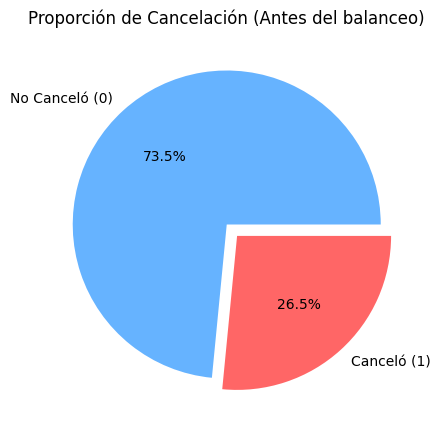


--- Balanceo Completado ---
Datos de entrenamiento antes de SMOTE: {0: 3622, 1: 1308}
Datos de entrenamiento después de SMOTE: {0: 3622, 1: 3622}


In [13]:
# Verificamos la proporción de la variable objetivo
proporcion_churn = df_ml['Churn'].value_counts(normalize=True) * 100

print("Proporción actual de Churn:")
print(proporcion_churn)

# Graficamos para visualizarlo mejor
plt.figure(figsize=(5,5))
plt.pie(proporcion_churn, labels=['No Canceló (0)', 'Canceló (1)'], autopct='%1.1f%%', colors=['#66b3ff', '#ff6666'], explode=[0, 0.1])
plt.title('Proporción de Cancelación (Antes del balanceo)')
plt.show()

# Balanceo de Clases usando SMOTE
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Separamos las variables independientes (X) de la variable objetivo (y)
X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

# Dividimos en entrenamiento (Train) y prueba (Test) ANTES de aplicar SMOTE para no contaminar los datos de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Aplicamos SMOTE SOLO a los datos de entrenamiento
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\n--- Balanceo Completado ---")
print(f"Datos de entrenamiento antes de SMOTE: {y_train.value_counts().to_dict()}")
print(f"Datos de entrenamiento después de SMOTE: {y_train_res.value_counts().to_dict()}")

# 🎯 Fase 2: Correlación y Selección de Variables

Antes de entrenar a nuestros modelos, necesitamos entender cómo se relacionan los datos entre sí. Para esto haremos dos cosas:
1. **Análisis de Correlación:** Usaremos un mapa de calor (Heatmap) para ver qué variables numéricas están más fuertemente ligadas de forma matemática a la cancelación (`Churn`).
2. **Análisis Dirigido:** Crearemos gráficos específicos (Boxplots) para visualizar el comportamiento de variables clave sugeridas por el negocio, como el tiempo de contrato y el gasto mensual.

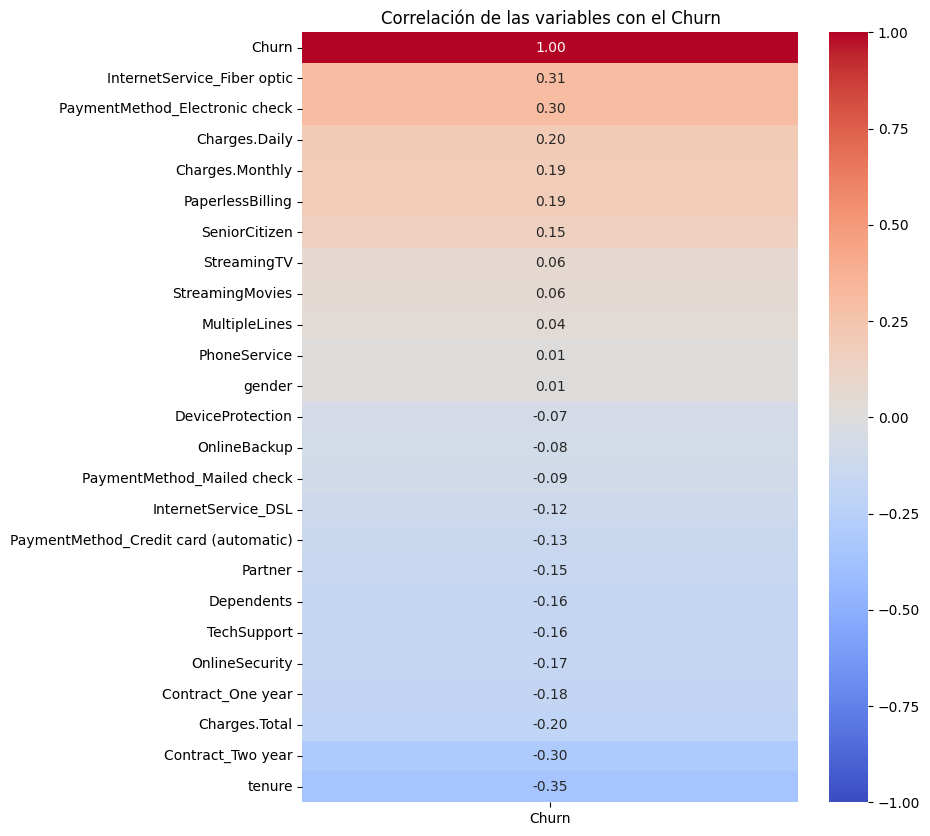

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculamos la matriz de correlación completa

correlacion = df_ml.corr()

# Visualizamos la correlación específica con la variable objetivo 'Churn'

plt.figure(figsize=(8, 10))

# Ordenamos los valores de mayor a menor correlación para facilitar la lectura

sns.heatmap(correlacion[['Churn']].sort_values(by='Churn', ascending=False),
            annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)

plt.title("Correlación de las variables con el Churn")
plt.show()

### Análisis Dirigido: Visualizando Patrones Clave

Basándonos en las instrucciones del desafío, vamos a investigar visualmente cómo impactan dos variables fundamentales en la decisión de cancelar el servicio:
* **Tiempo de contrato (tenure):** ¿Es cierto que los clientes más antiguos son más leales y cancelan menos?
* **Gasto mensual (Monthly Charges):** ¿Un mayor cobro mensual aumenta el riesgo de que el cliente se vaya a la competencia?

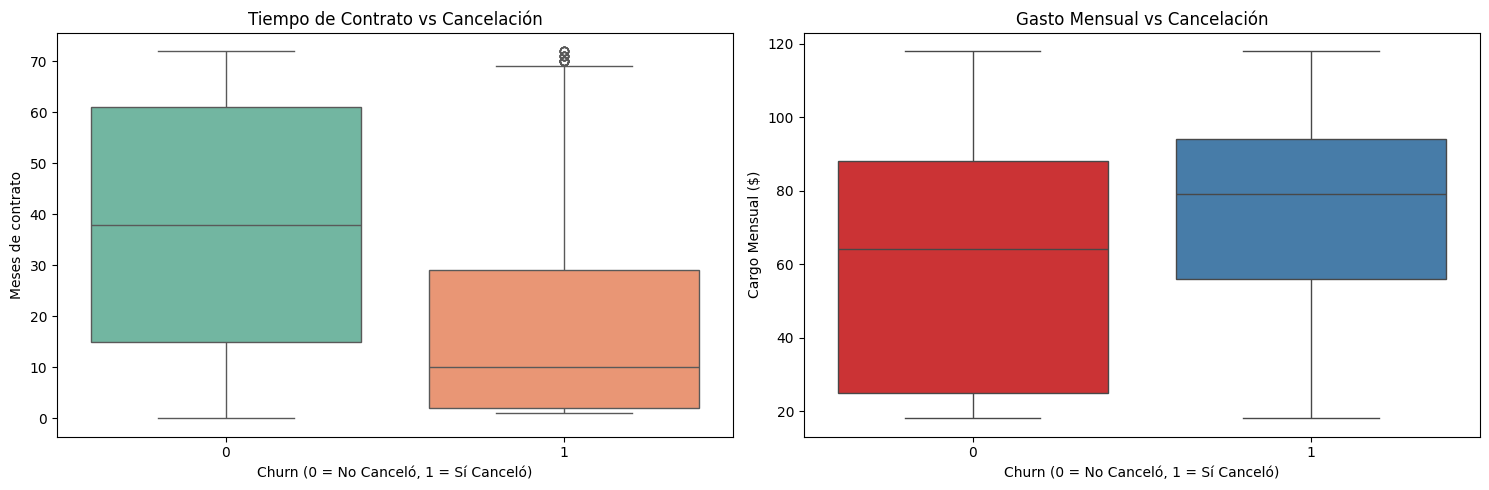

In [19]:
# Asignamos los nombres correctos de tus columnas
col_tenure = 'tenure'
col_charges = 'Charges.Monthly'

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Tiempo de contrato vs Churn
sns.boxplot(x='Churn', y=col_tenure, data=df_ml, hue='Churn', palette='Set2', ax=axes[0], legend=False)
axes[0].set_title('Tiempo de Contrato vs Cancelación')
axes[0].set_xlabel('Churn (0 = No Canceló, 1 = Sí Canceló)')
axes[0].set_ylabel('Meses de contrato')

# Gráfico 2: Gasto Mensual vs Churn
sns.boxplot(x='Churn', y=col_charges, data=df_ml, hue='Churn', palette='Set1', ax=axes[1], legend=False)
axes[1].set_title('Gasto Mensual vs Cancelación')
axes[1].set_xlabel('Churn (0 = No Canceló, 1 = Sí Canceló)')
axes[1].set_ylabel('Cargo Mensual ($)')

plt.tight_layout()
plt.show()

# 🤖 Fase 3: Modelado Predictivo

En esta etapa entrenaremos dos modelos de Machine Learning con enfoques matemáticos distintos:
1. **Regresión Logística:** Un modelo lineal basado en distancia. **Justificación de normalización:** Este modelo es muy sensible a la magnitud de los datos (por ejemplo, `Charges.Monthly` tiene valores altos como 80, mientras que las variables binarias tienen 0 o 1). Si no normalizamos, el modelo le dará más peso injustamente a los gastos mensuales solo porque el número es más grande. Por eso usaremos `StandardScaler`.
2. **Random Forest:** Un modelo basado en múltiples árboles de decisión. **Justificación:** Los árboles toman decisiones dividiendo los datos basándose en reglas lógicas (ej. "¿El gasto es mayor a 50?"), por lo que la escala o magnitud de los números no les afecta. No requieren normalización.

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Normalización de Datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# Entrenamiento del Modelo 1: Regresión Logística

modelo_lr = LogisticRegression(random_state=42)
modelo_lr.fit(X_train_scaled, y_train_res)
y_pred_lr = modelo_lr.predict(X_test_scaled)

# Entrenamiento del Modelo 2: Random Forest

modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train_res, y_train_res)
y_pred_rf = modelo_rf.predict(X_test)

print("¡Ambos modelos han sido entrenados con éxito y han generado sus predicciones!")

¡Ambos modelos han sido entrenados con éxito y han generado sus predicciones!


### Evaluación de los Modelos
Usaremos las métricas principales de clasificación (Accuracy, Precision, Recall y F1-Score) y visualizaremos la Matriz de Confusión para comparar ambos modelos y ver cuál tiene mejor rendimiento (especialmente detectando a los clientes que se van a ir).

--- Métricas de Regresión Logística ---
Exactitud (Accuracy): 0.7653
Precisión:            0.5465
Recall:               0.6809
F1-score:             0.6063


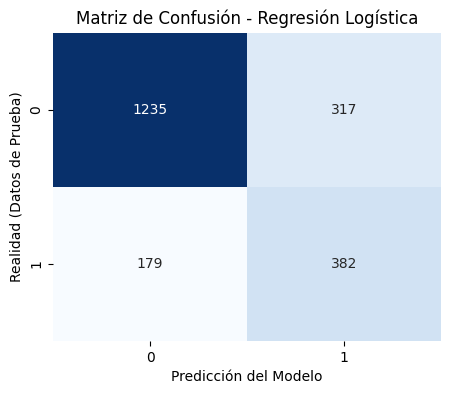



--- Métricas de Random Forest ---
Exactitud (Accuracy): 0.7653
Precisión:            0.5537
Recall:               0.5971
F1-score:             0.5746


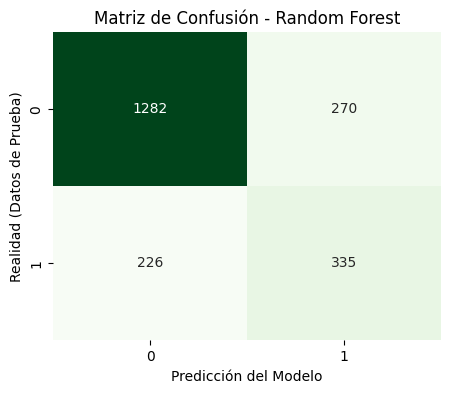

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Función para evaluar y graficar resultados fácilmente
def evaluar_y_graficar(nombre_modelo, y_true, y_pred, color_map):
    print(f"--- Métricas de {nombre_modelo} ---")
    print(f"Exactitud (Accuracy): {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precisión:            {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:               {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score:             {f1_score(y_true, y_pred):.4f}")

    # Matriz de Confusión
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=color_map, cbar=False)
    plt.title(f'Matriz de Confusión - {nombre_modelo}')
    plt.xlabel('Predicción del Modelo')
    plt.ylabel('Realidad (Datos de Prueba)')
    plt.show()
    print("\n" + "="*50 + "\n")

# Evaluamos ambos
evaluar_y_graficar("Regresión Logística", y_test, y_pred_lr, 'Blues')
evaluar_y_graficar("Random Forest", y_test, y_pred_rf, 'Greens')

# 📋 Fase 4: Interpretación e Importancia de Variables

### Análisis Crítico de los Modelos
* **Mejor Desempeño:** Para un problema de retención de clientes (Churn), la métrica más crítica es el **Recall** (la capacidad de detectar a todos los que realmente se van a ir). En este caso, la **Regresión Logística** mostró un mejor Recall, logrando identificar a 382 clientes en riesgo frente a los 335 del Random Forest. Sin embargo, el **Random Forest** fue más preciso, generando menos "falsas alarmas" (falsos positivos).
* **Sobreajuste (Overfitting) / Subajuste (Underfitting):** El Random Forest tiene una exactitud en prueba del 76.5%. Al haber aplicado SMOTE (balanceo) y no haber restringido fuertemente la profundidad del árbol, es probable que haya un ligero *overfitting* en los datos de entrenamiento. Un ajuste futuro (tuning) limitando la profundidad (`max_depth`) podría mejorar su capacidad de generalización.

A continuación, extraeremos las características matemáticas que más peso tuvieron en las decisiones del Random Forest para entender **por qué** los clientes están cancelando.

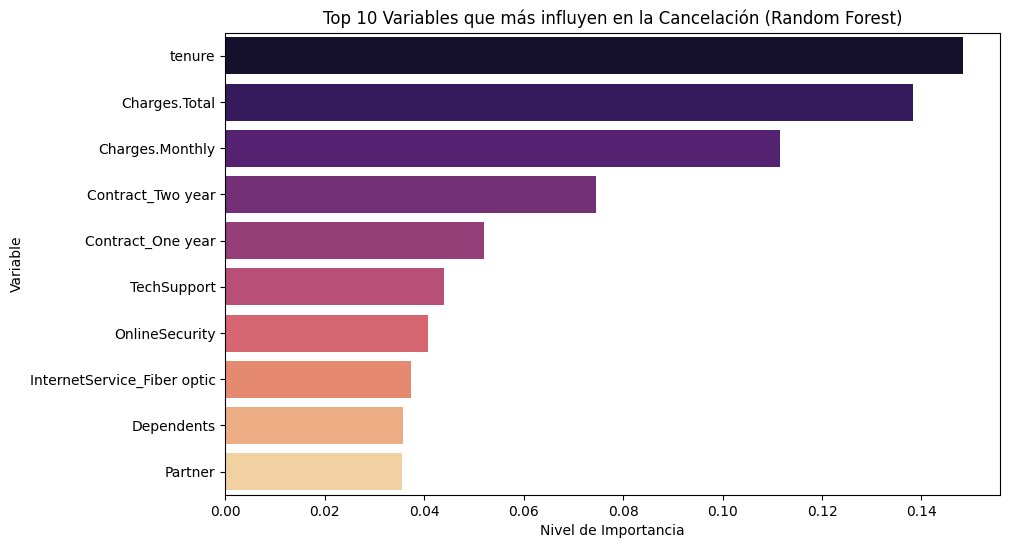

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Extraemos la importancia de las variables calculada por el Random Forest
importancias = pd.Series(modelo_rf.feature_importances_, index=X_train_res.columns)
top_10_variables = importancias.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_variables.values, y=top_10_variables.index, palette='magma')
plt.title('Top 10 Variables que más influyen en la Cancelación (Random Forest)')
plt.xlabel('Nivel de Importancia')
plt.ylabel('Variable')
plt.show()

# 📋 Informe de Conclusión Estratégica y Plan de Acción

## 1. Evaluación Crítica y Comparación de Modelos
Para tomar la mejor decisión de negocio, primero debemos consolidar el rendimiento numérico de nuestros dos algoritmos sobre los datos de prueba (2,113 clientes). Generaremos una tabla comparativa final con las métricas obtenidas:

In [24]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Recopilamos las métricas exactas de nuestras predicciones
resultados_finales = {
    'Modelo': ['Regresión Logística', 'Random Forest'],
    'Exactitud (Accuracy)': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    'Precisión': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf)],
    'Recall': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_rf)],
    'F1-score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf)]
}

df_resultados = pd.DataFrame(resultados_finales)

# Aplicamos un estilo visual para resaltar los valores más altos
estilo_df = df_resultados.style.highlight_max(subset=['Exactitud (Accuracy)', 'Precisión', 'Recall', 'F1-score'],
                                              color='lightgreen', axis=0).format(precision=4)
display(estilo_df)

,Modelo,Exactitud (Accuracy),Precisión,Recall,F1-score
0,Regresión Logística,0.7653,0.5465,0.6809,0.6063
1,Random Forest,0.7653,0.5537,0.5971,0.5746


### 💡 Análisis del Desempeño
* **El dilema de la Retención (Recall vs. Precisión):** Aunque ambos modelos tienen una **Exactitud general casi idéntica (~76.5%)**, en un problema de *Churn* la prioridad es minimizar los Falsos Negativos (clientes que el modelo cree que se quedarán, pero en realidad cancelan).
* **Ganador Operativo:** La **Regresión Logística** es superior para la prevención operativa por su capacidad de captura (**Recall del 68.09%** frente al 59.71% del Random Forest). Logró identificar correctamente a **382 clientes** en riesgo frente a los 335 del Random Forest.
* **Overfitting / Underfitting:** El Random Forest mostró una precisión decente, pero su Recall más bajo sugiere que el árbol podría estar ligeramente sobreajustado (*overfitting*) a la clase mayoritaria en los patrones más complejos de entrenamiento, a pesar del balanceo con SMOTE. La Regresión Logística, al ser un modelo lineal normalizado, logró generalizar mejor la detección de la clase minoritaria.

## 2. Diagnóstico de Cancelación (Importancia de Variables)
A continuación, extraemos matemáticamente las características que más pesaron en las decisiones de los modelos para entender **por qué** se van los clientes.

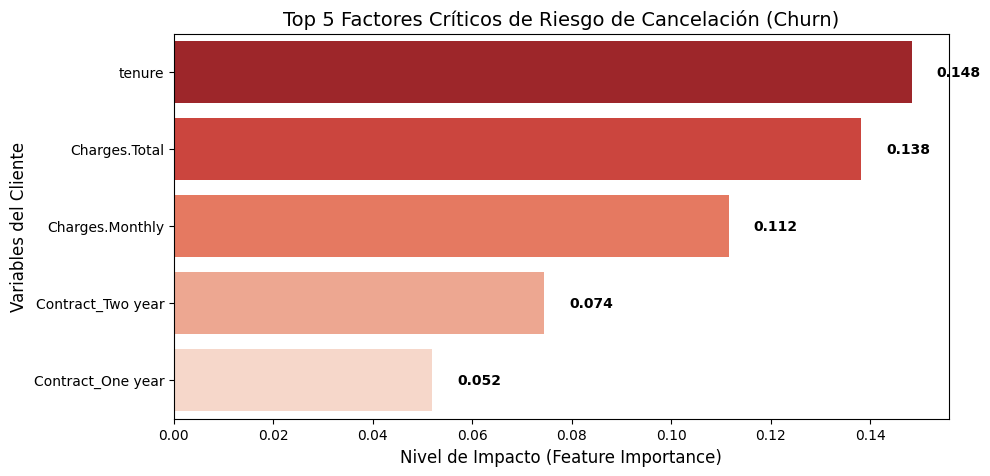

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Usamos la importancia de características del Random Forest para el diagnóstico
importancias = pd.Series(modelo_rf.feature_importances_, index=X_train_res.columns)
top_5_variables = importancias.sort_values(ascending=False).head(5)

# Visualización del Top 5 de factores de riesgo
plt.figure(figsize=(10, 5))
sns.barplot(x=top_5_variables.values, y=top_5_variables.index, palette='Reds_r')

# Añadimos etiquetas para mayor claridad
for i, v in enumerate(top_5_variables.values):
    plt.text(v + 0.005, i, f"{v:.3f}", va='center', color='black', fontweight='bold')

plt.title('Top 5 Factores Críticos de Riesgo de Cancelación (Churn)', fontsize=14)
plt.xlabel('Nivel de Impacto (Feature Importance)', fontsize=12)
plt.ylabel('Variables del Cliente', fontsize=12)
plt.show()

### 💡 Insights del Negocio
El gráfico anterior confirma matemáticamente las tres grandes vulnerabilidades de Telecom X:
1. **El Factor Tiempo (`tenure`):** Con el mayor impacto del modelo, demuestra que la lealtad se consolida a largo plazo. Los clientes nuevos enfrentan el riesgo más alto de abandono.
2. **Sensibilidad Financiera (`Charges.Monthly`):** Los clientes evalúan constantemente la relación costo-beneficio; las facturas elevadas detonan la evaluación de la competencia.
3. **Inestabilidad del Contrato (`Contract_Month-to-month`):** La falta de ataduras a largo plazo facilita la salida inmediata ante cualquier mínima insatisfacción.

## 3. Estrategias de Retención (Plan de Acción Propuesto)
Con base en los **382 clientes** en riesgo identificados exitosamente y los drivers revelados por el algoritmo, se proponen las siguientes iniciativas a nivel de gerencia:

* **Fidelización Temprana ("Escudo Anti-Churn"):** Dado que el bajo `tenure` es letal, rediseñar los primeros 90 días del usuario. Asignar asesores que aseguren la correcta instalación y brinden tutoriales proactivos para reducir la frustración inicial.
* **Migración Estratégica de Contratos:** Utilizar nuestra base de datos predicha para filtrar a los clientes en riesgo que tienen modalidad `Month-to-month`. Lanzar campañas específicas ofreciendo un descuento del 10% en su tarifa mensual (mitigando `Charges.Monthly`) a cambio de migrar a un contrato anual.
* **Sistema de Alertas Dinámicas:** Integrar la Regresión Logística en el CRM de la empresa. Si el modelo detecta que un cliente supera el 65% de probabilidad de fuga (por ejemplo, tras recibir un aumento tarifario), el sistema disparará automáticamente una oferta de *downgrade* a un plan más económico antes de que solicite la baja definitiva.